In [29]:
# ─────────────────────────────────────────────
# 0 : Loading
# ─────────────────────────────────────────────

%reload_ext autoreload
%autoreload 2

In [30]:
# ─────────────────────────────────────────────
# 1.1 : Python Version
# ─────────────────────────────────────────────

import sys, site
print("Python:", sys.executable)
print("User site:", site.getusersitepackages())
print("Site-packages:", site.getsitepackages() if hasattr(site, "getsitepackages") else "n/a")


# ─────────────────────────────────────────────
# 1.2 : Librairies
# ─────────────────────────────────────────────

import pickle
import numpy as np
import polars as pl
import pyarrow.parquet as pq

from pathlib import Path
from matplotlib import pyplot as plt
from tqdm import tqdm

from nucleo.io.reading import getting_main_file_with_verifications

plt.rcParams["font.size"] = 12

Python: /home/nicolas/Documents/Workspace/nucleo/.venv_nucleo_3.12.3/bin/python
User site: /home/nicolas/.local/lib/python3.12/site-packages
Site-packages: ['/home/nicolas/Documents/Workspace/nucleo/.venv_nucleo_3.12.3/lib/python3.12/site-packages', '/home/nicolas/Documents/Workspace/nucleo/.venv_nucleo_3.12.3/local/lib/python3.12/dist-packages', '/home/nicolas/Documents/Workspace/nucleo/.venv_nucleo_3.12.3/lib/python3/dist-packages', '/home/nicolas/Documents/Workspace/nucleo/.venv_nucleo_3.12.3/lib/python3.12/dist-packages']


In [31]:
# ─────────────────────────────────────────────
# 2.1 : Main file + Verification
# ─────────────────────────────────────────────

# Locating
root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-05-01")
main_file_path = root / "ncl_output.parquet"

# Reading
data = pq.read_table(main_file_path)
df_polars = pl.DataFrame(data)

# Loading file + Filtering
df_main = getting_main_file_with_verifications(df_polars)
print('The df_polars containing the int and floats for all our simulations :\nTotal shape :',df_main.shape, '\nQuick print and shape :', df_main.head(5))

The df_polars containing the int and floats for all our simulations :
Total shape : (131300, 26) 
Quick print and shape : shape: (5, 26)
┌─────┬─────┬───────┬─────┬───┬────────────┬───────────┬────────────┬───────┐
│ s   ┆ l   ┆ bpmin ┆ mu  ┆ … ┆ wf_std     ┆ vi_mean   ┆ vi_med     ┆ vi_mp │
│ --- ┆ --- ┆ ---   ┆ --- ┆   ┆ ---        ┆ ---       ┆ ---        ┆ ---   │
│ i64 ┆ i64 ┆ i64   ┆ i64 ┆   ┆ f64        ┆ f64       ┆ f64        ┆ f64   │
╞═════╪═════╪═══════╪═════╪═══╪════════════╪═══════════╪════════════╪═══════╡
│ 150 ┆ 10  ┆ 5     ┆ 100 ┆ … ┆ 0.00298    ┆ 46.500589 ┆ 1.05345    ┆ 0.5   │
│ 150 ┆ 10  ┆ 5     ┆ 100 ┆ … ┆ 0.409224   ┆ 0.00189   ┆ 0.0        ┆ 0.5   │
│ 150 ┆ 10  ┆ 5     ┆ 100 ┆ … ┆ 1.4762e-15 ┆ 0.022893  ┆ 1.9779e-32 ┆ 0.5   │
│ 150 ┆ 10  ┆ 5     ┆ 100 ┆ … ┆ 0.079373   ┆ 0.017485  ┆ 5.0500e-27 ┆ 0.5   │
│ 150 ┆ 10  ┆ 5     ┆ 100 ┆ … ┆ 0.062594   ┆ 0.08184   ┆ 5.0055e-23 ┆ 0.5   │
└─────┴─────┴───────┴─────┴───┴────────────┴───────────┴────────────┴───────┘


In [32]:
# ─────────────────────────────────────────────
# 2.2 : Heatmaps
# ─────────────────────────────────────────────


from nucleo.io.plots import plot_single_heatmap, plot_all_heatmaps


with open(root / "ncl_hm_raw.pkl", "rb") as f:
    computed_data = pickle.load(f)

key, config_data = next(iter(computed_data.items()))

mu_values = config_data["mu_values"]
theta_values = config_data["theta_values"]
data = config_data["v_mean"]
config = config_data["config"]

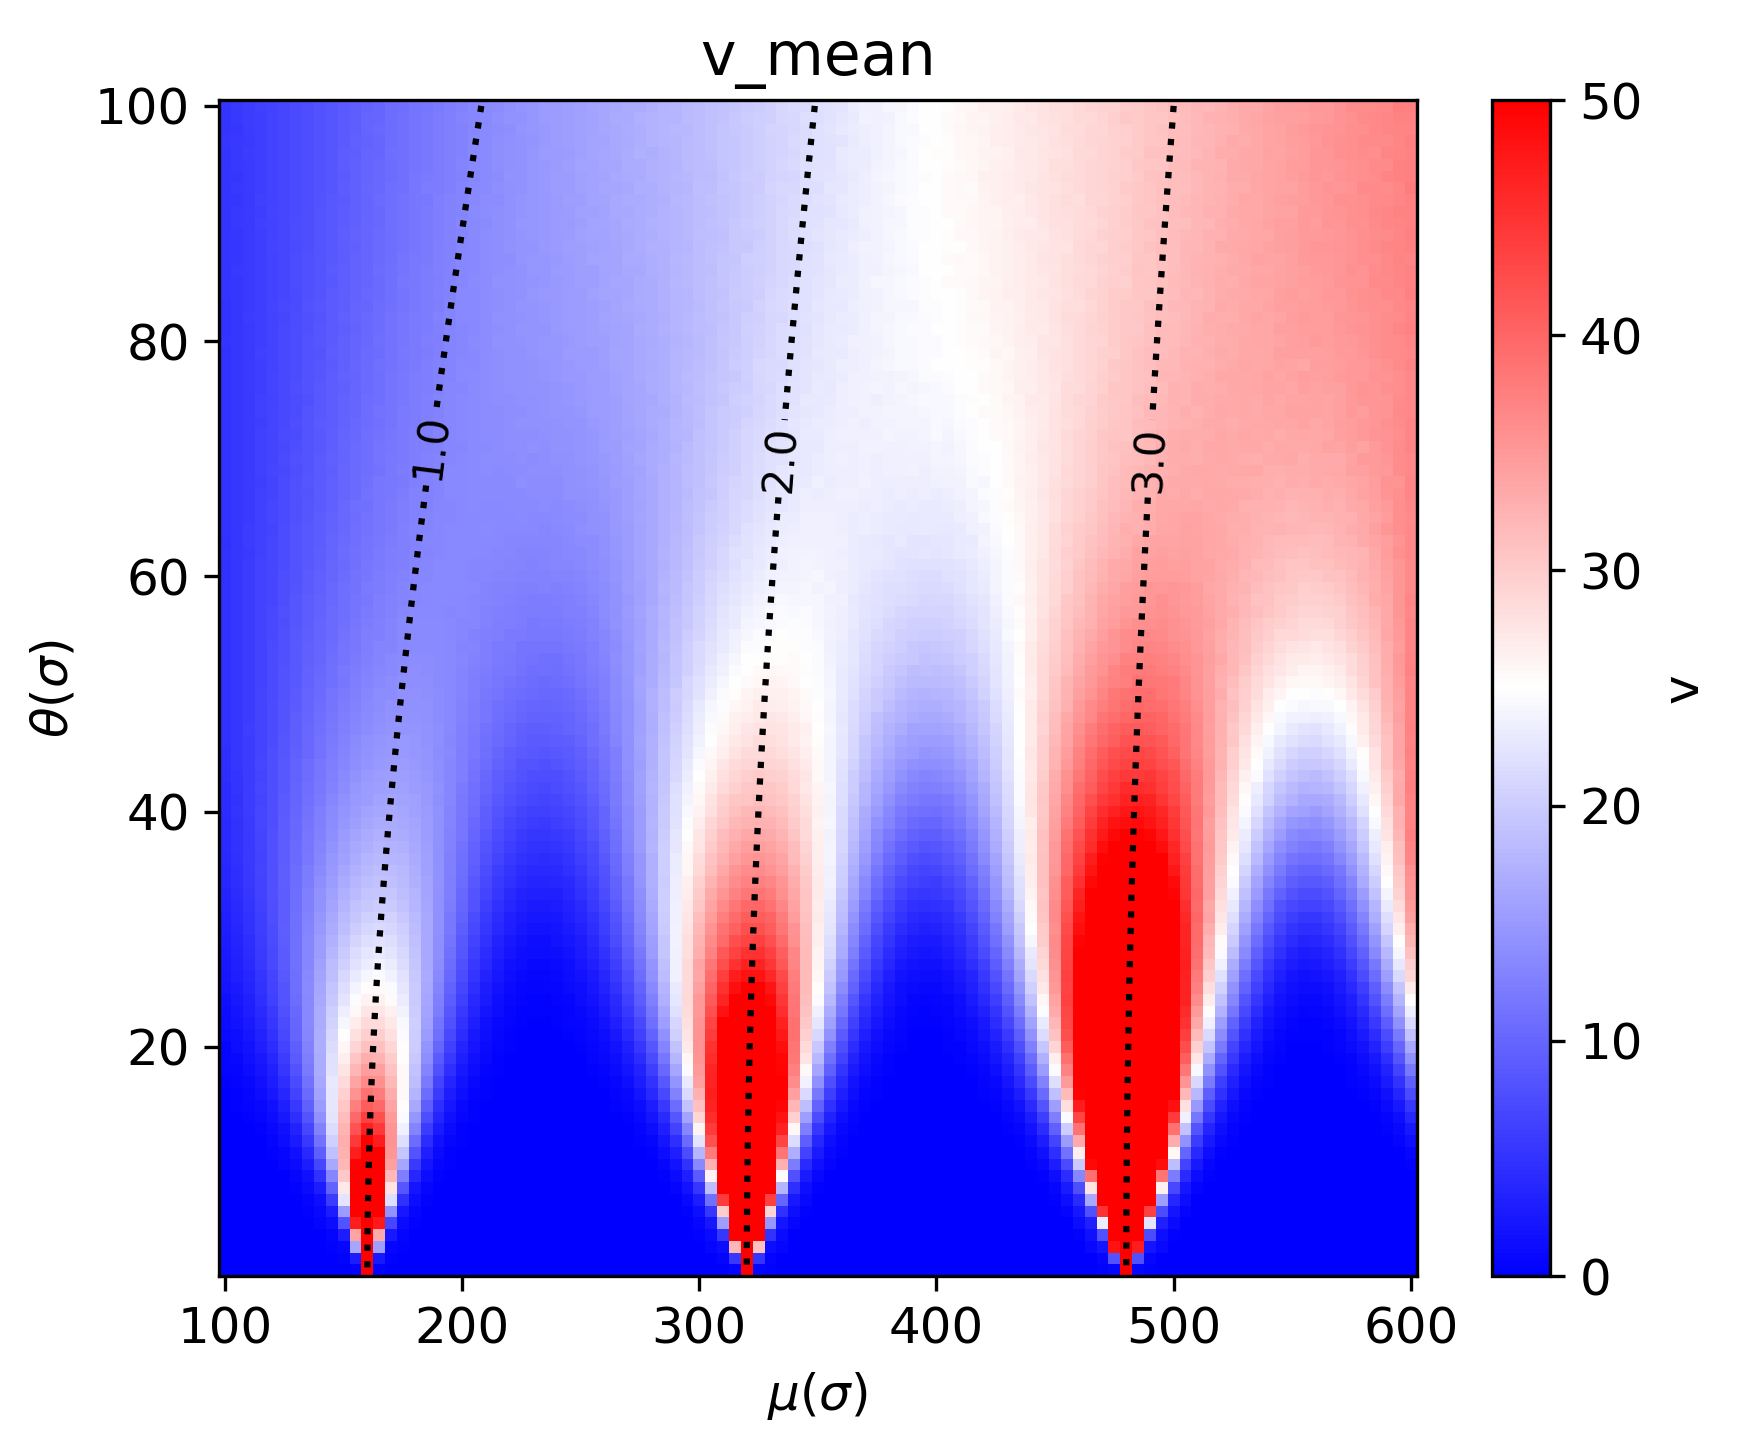

In [33]:
fig, ax = plt.subplots(figsize=(6,5), dpi=300)

plot_single_heatmap(
    ax=ax,
    mu_values=mu_values,
    theta_values=theta_values,
    data=data,
    speed_col="v_mean",
    config=config,
    plot_log2=False,
    vmin=0,
    vmax=50,
    title_bar="v"
)

plt.tight_layout()
plt.show()

In [36]:
plot_all_heatmaps(
    speed_cols=["v_mean", "vf", "wf"],
    root=root,
    type_of_data="norm_th",
    plot_log2=False
)

Plotting heatmaps: 100%|██████████| 13/13 [00:00<00:00, 24.88it/s]


# .